<a href="https://colab.research.google.com/github/shreyalovespeanuts/student-performance-predictor/blob/main/Student_Performance_Prediction_Shreya_A25305223164_BTechMinorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing essential libraries
import pandas as pd
import numpy as np
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
# Machine learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [1]:
from google.colab import files
uploaded = files.upload()

Saving student_habits_performance.csv to student_habits_performance.csv


In [ ]:
import pandas as pd
df = pd.read_csv("student_habits_performance.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [ ]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [ ]:
df = df.drop("student_id", axis=1)

In [ ]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
df.fillna(df.mean(), inplace=True)

In [ ]:
df["performance"] = df["exam_score"].apply(lambda x: 1 if x >= 50 else 0)

df = df.drop("exam_score", axis=1)

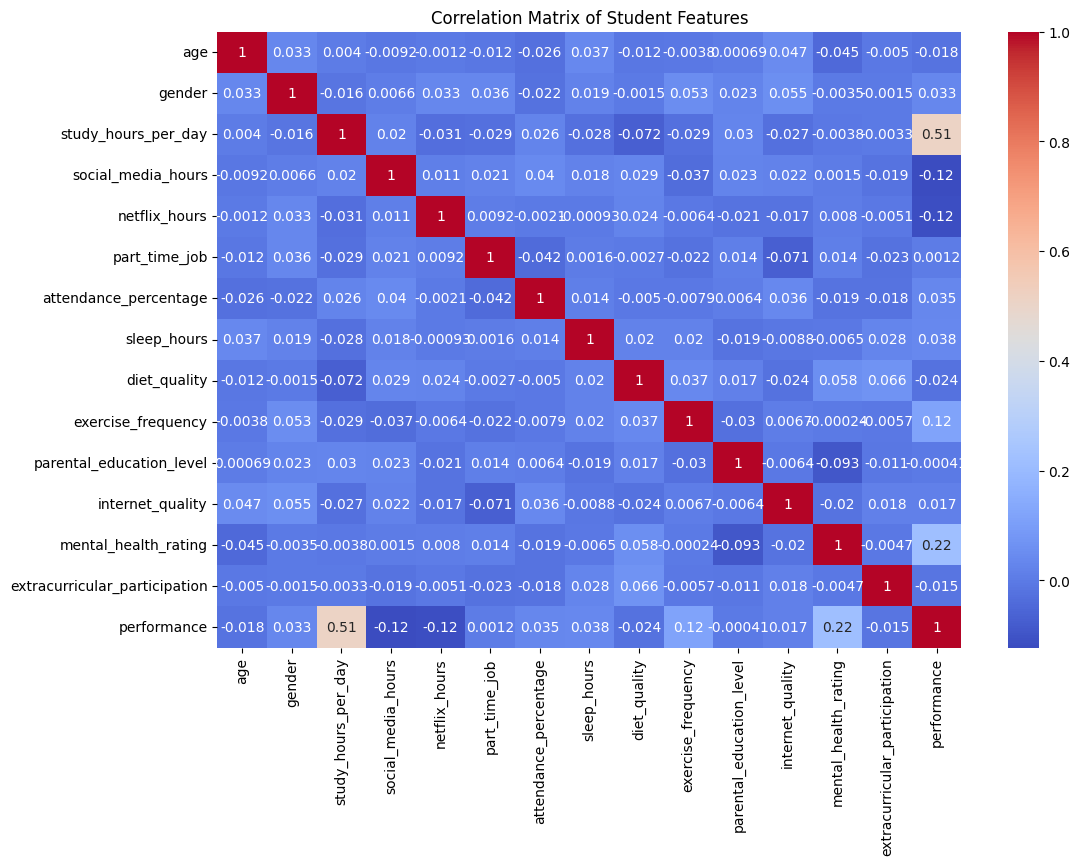

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Student Features")
plt.show()

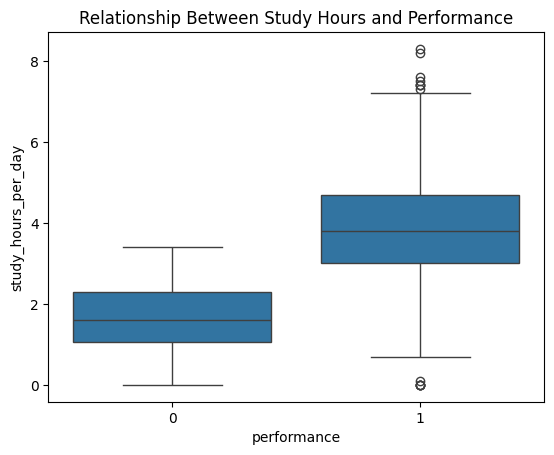

In [ ]:
sns.boxplot(x='performance', y='study_hours_per_day', data=df)
plt.title("Relationship Between Study Hours and Performance")
plt.show()

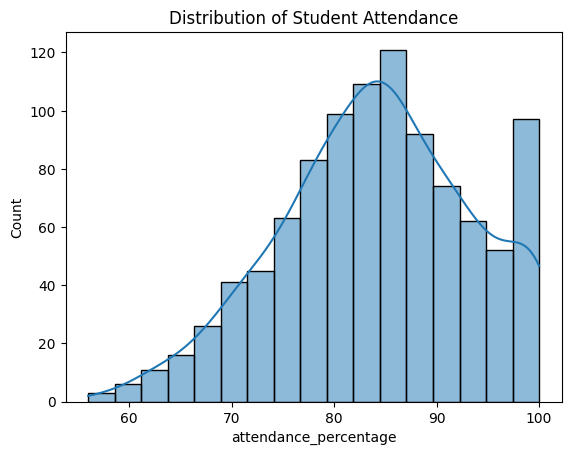

In [ ]:
sns.histplot(df['attendance_percentage'], kde=True)
plt.title("Distribution of Student Attendance")
plt.show()

In [ ]:
X = df.drop("performance", axis=1)
y = df["performance"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [ ]:
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.945
[[ 22   6]
 [  5 167]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.97      0.97      0.97       172

    accuracy                           0.94       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.94      0.94      0.94       200



In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.905
[[ 20   8]
 [ 11 161]]
              precision    recall  f1-score   support

           0       0.65      0.71      0.68        28
           1       0.95      0.94      0.94       172

    accuracy                           0.91       200
   macro avg       0.80      0.83      0.81       200
weighted avg       0.91      0.91      0.91       200



In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.94
[[ 17  11]
 [  1 171]]
              precision    recall  f1-score   support

           0       0.94      0.61      0.74        28
           1       0.94      0.99      0.97       172

    accuracy                           0.94       200
   macro avg       0.94      0.80      0.85       200
weighted avg       0.94      0.94      0.93       200



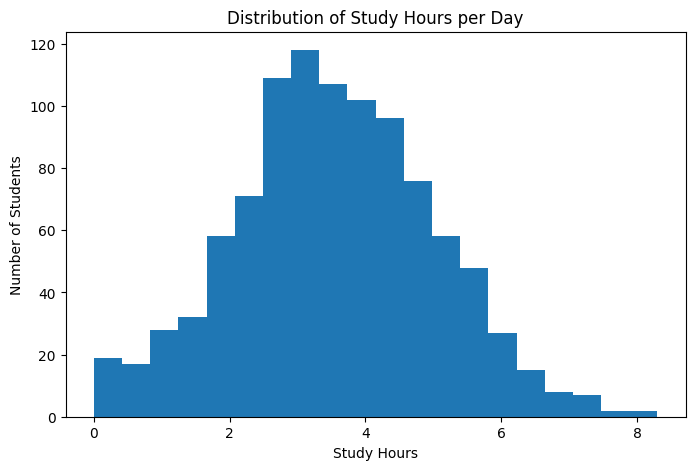

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['study_hours_per_day'], bins=20)
plt.title("Distribution of Study Hours per Day")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.show()

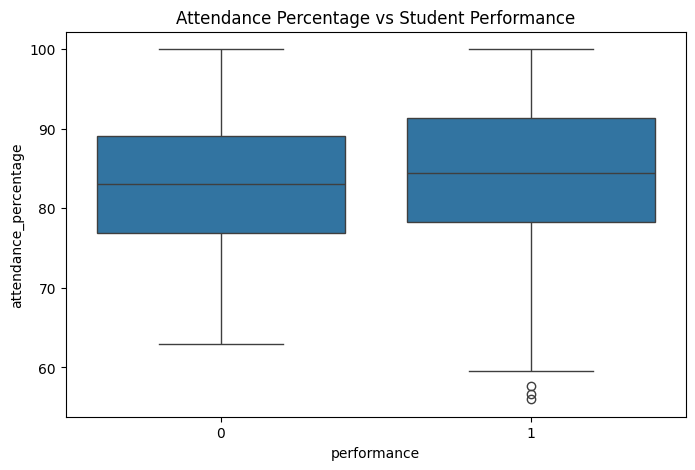

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='performance', y='attendance_percentage', data=df)
plt.title("Attendance Percentage vs Student Performance")
plt.show()

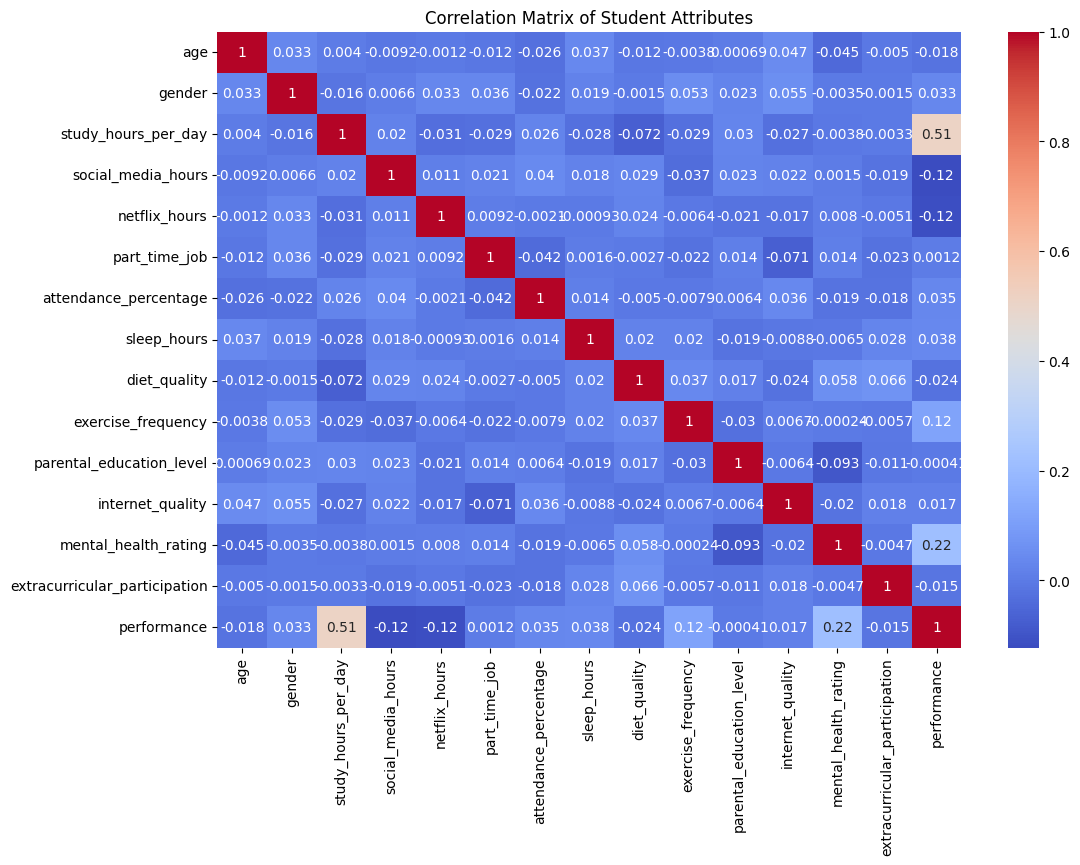

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Student Attributes")
plt.show()

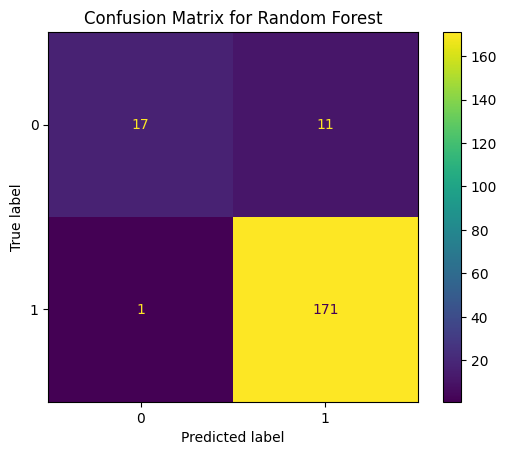

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Confusion Matrix for Random Forest")
plt.show()

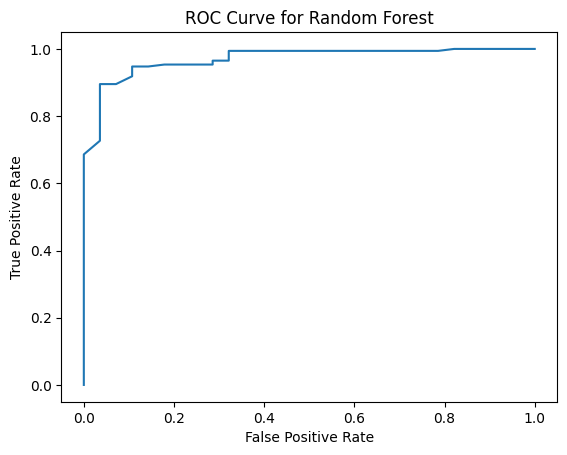

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title("ROC Curve for Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

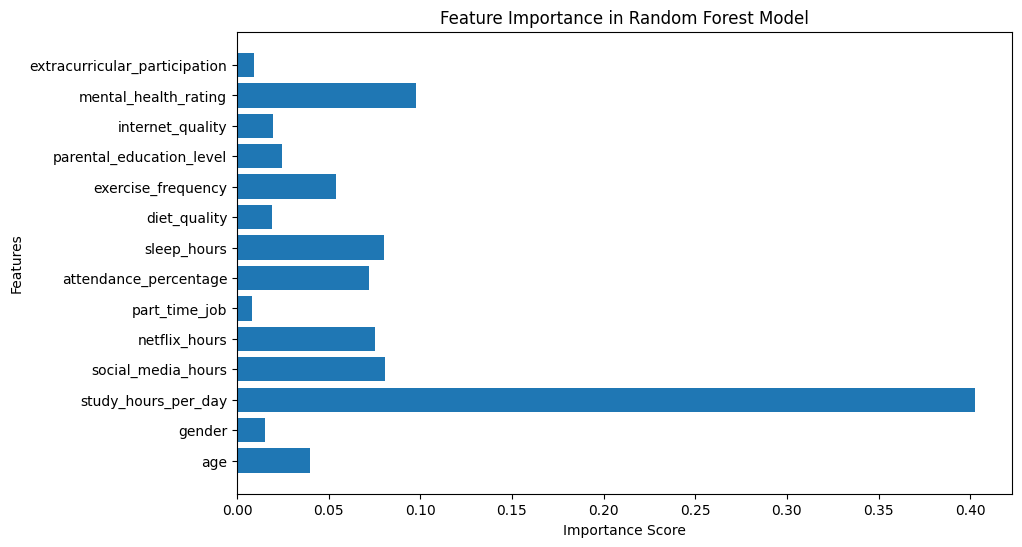

In [ ]:
importances = rf_model.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

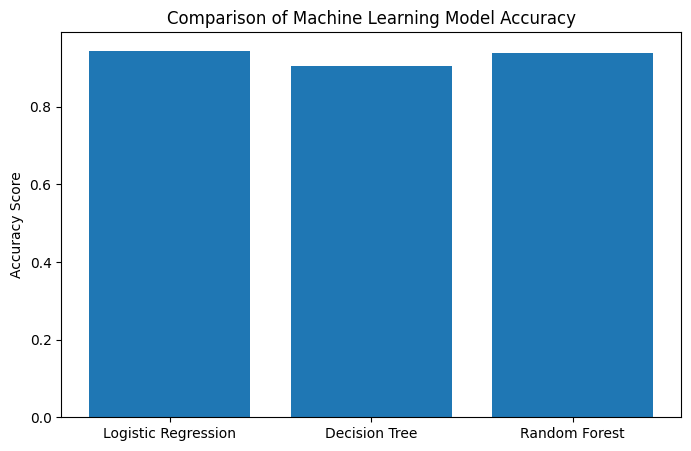

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [log_accuracy, dt_accuracy, rf_accuracy]
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Comparison of Machine Learning Model Accuracy")
plt.ylabel("Accuracy Score")
plt.show()

In [ ]:
def test_high_performance():
    assert predict_performance(80) == "High Performance"

def test_low_performance():
    assert predict_performance(40) == "Low Performance"


In [ ]:
def predict_performance(score):
    if score >= 50:
        return "High Performance"
    else:
        return "Low Performance"

def test_high():
    assert predict_performance(80) == "High Performance"

def test_low():
    assert predict_performance(30) == "Low Performance"

test_high()
test_low()

print("All tests passed")

All tests passed


In [ ]:
import unittest

In [ ]:
import unittest
def predict_performance(score):
    return "Unknown"
class TestPerformance(unittest.TestCase):
    def test_high_performance(self):
        self.assertEqual(predict_performance(80), "High Performance")
    def test_low_performance(self):
        self.assertEqual(predict_performance(40), "Low Performance")
if __name__ == "__main__":
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

FF
FAIL: test_high_performance (__main__.TestPerformance.test_high_performance)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_5902/1266917850.py", line 10, in test_high_performance
    self.assertEqual(predict_performance(80), "High Performance")
AssertionError: 'Unknown' != 'High Performance'
- Unknown
+ High Performance


FAIL: test_low_performance (__main__.TestPerformance.test_low_performance)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_5902/1266917850.py", line 13, in test_low_performance
    self.assertEqual(predict_performance(40), "Low Performance")
AssertionError: 'Unknown' != 'Low Performance'
- Unknown
+ Low Performance


----------------------------------------------------------------------
Ran 2 tests in 0.009s

FAILED (failures=2)


In [ ]:
scores = [35, 48, 50, 67, 82]

for score in scores:
    result = predict_performance(score)
    print("Exam Score:", score, "->", result)

Exam Score: 35 -> Low Performance
Exam Score: 48 -> Low Performance
Exam Score: 50 -> High Performance
Exam Score: 67 -> High Performance
Exam Score: 82 -> High Performance


In [ ]:
# Final validation tests
assert predict_performance(90) == "High Performance"
assert predict_performance(25) == "Low Performance"
assert predict_performance(50) == "High Performance"
print("All validation tests passed successfully.")

All validation tests passed successfully.


In [ ]:
def predict_performance(score):
    if score >= 50:
        return "High Performance"
    else:
        return "Low Performance"

In [ ]:
import unittest
class TestPerformance(unittest.TestCase):
    def test_high_performance(self):
        self.assertEqual(predict_performance(80), "High Performance")
    def test_low_performance(self):
        self.assertEqual(predict_performance(40), "Low Performance")
if __name__ == "__main__":
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

..
----------------------------------------------------------------------
Ran 2 tests in 0.009s

OK


In [ ]:
def predict_performance(score):
    return "High Performance" if score >= 50 else "Low Performance"